# Does silencing a loop anchor break the loop?

A real use of the spec-based inference: take a **predicted chromatin loop**, silence each of its two anchors *in silico*, and see whether the model says the loop depends on them. Model: **Krietenstein Micro-C** (2048 bp, H1-ESC + HFFc6 channels); locus: a strong loop on **chr22** the model predicts on its own. All data is in `manta_demo/data/` (see its README).

The workflow is one `predict_region` call over four conditions — wild type, silence anchor A, silence anchor B, silence both — each averaged over the cache's runs and both orientations.

In [15]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))  # repo root, so this dev tree's `manta_hic` is importable
%matplotlib inline
import numpy as np, torch, pysam
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from manta_hic.nn.fetchers import CachedMicrozoiFetcher
from manta_hic.nn.inference import MantaInference

D = 'data/'  # this notebook lives in manta_demo/; download the files into manta_demo/data/ (see its README)


fetcher = CachedMicrozoiFetcher(D + 'cache_hg38_chr22_2runs.h5', fasta_open=pysam.FastaFile(D + 'hg38.fa'))
infer = MantaInference(D + 'krietenstein_2048.pth', fetcher, device='cuda:0', target=D + 'krietenstein_2048.bhic.h5')
print('resolution (from checkpoint):', infer.resolution, '| channels:', infer.channel_names, '| cache runs:', int(fetcher.N_runs))

resolution (from checkpoint): 2048 | channels: ['krietenstein-esc', 'krietenstein-hff1'] | cache runs: 2


## 1. The locus: predicted vs observed
A 2.1 Mb window on chr22. The model (left) reproduces the observed Micro-C (right); a focal **loop** sits off the diagonal (boxed). Its two anchors are candidate regulatory/CTCF elements.

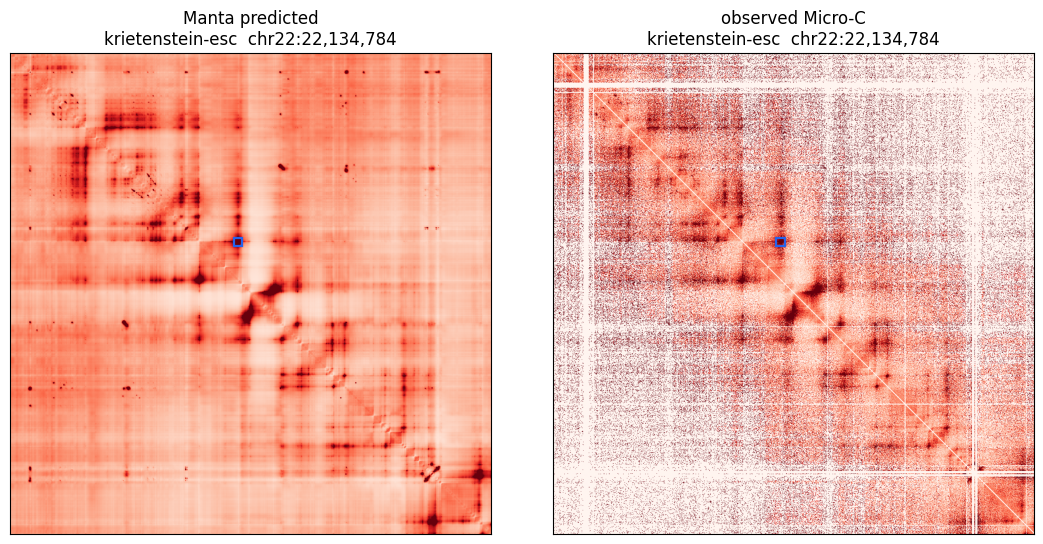

loop anchors: chr22:22,958,080 and chr22:23,128,064  (170 kb apart)


In [16]:
CH = 0  # channel 0 = krietenstein-esc
START = 22_134_784                       # window start (bp)
A1_BIN, A2_BIN = 402, 485                 # loop anchors, in map bins (chr22:22.96 Mb <-> 23.13 Mb)
res = infer.resolution

pred = infer.predict('chr22', START, run_idx=0)[CH].float().cpu().numpy()
obs  = infer.target('chr22', START)[CH].float().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 5.4))
vmax = np.nanpercentile(pred, 99.5)
for a, img, ttl in ((ax[0], pred, 'Manta predicted'), (ax[1], obs, 'observed Micro-C')):
    a.imshow(img, cmap='Reds', vmax=vmax, vmin=0)
    a.add_patch(Rectangle((A2_BIN-9, A1_BIN-9), 18, 18, fill=False, ec='#2563eb', lw=1.6))
    a.set_title(f'{ttl}\n{infer.channel_names[CH]}  chr22:{START:,}'); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print(f'loop anchors: chr22:{START+A1_BIN*res:,} and chr22:{START+A2_BIN*res:,}  ({(A2_BIN-A1_BIN)*res/1000:.0f} kb apart)')

## 2. Silence each anchor and re-predict
Silence = `inactivate` a ~3 kb window at each anchor (replace it with inert sequence). Four conditions in one call, matched (all share each background) and averaged over both cache runs + orientations.

In [17]:
a1_bp, a2_bp = START + A1_BIN * res, START + A2_BIN * res
A1 = ("inactivate", a1_bp - 1500, a1_bp + 1500)
A2 = ("inactivate", a2_bp - 1500, a2_bp + 1500)
conditions = {"WT": [], "silence-A1": [A1], "silence-A2": [A2], "silence-both": [A1, A2]}

maps, names = infer.predict_region(
    "chr22",
    START,
    conditions,  # A list of 4 conditions 
    runs=2,  # For each condition, average two different runs of Manta 
    rc="average",  # Also average reverse complement
    backgrounds="matched",  # All 4 conditions have matched backgrounds (same offsets / tiling of Microzoi)
    rng_seed=0,  # For reproducibility
)
maps = {k: v[CH].float().cpu().numpy() for k, v in maps.items()}
print("conditions:", list(maps))

conditions: ['WT', 'silence-A1', 'silence-A2', 'silence-both']


## 3. The loop weakens when either anchor is silenced
Top row: the predicted map per condition (loop boxed). Bottom row: change vs wild type (blue = weakened). Silencing either anchor dims the focal loop; silencing both removes it.

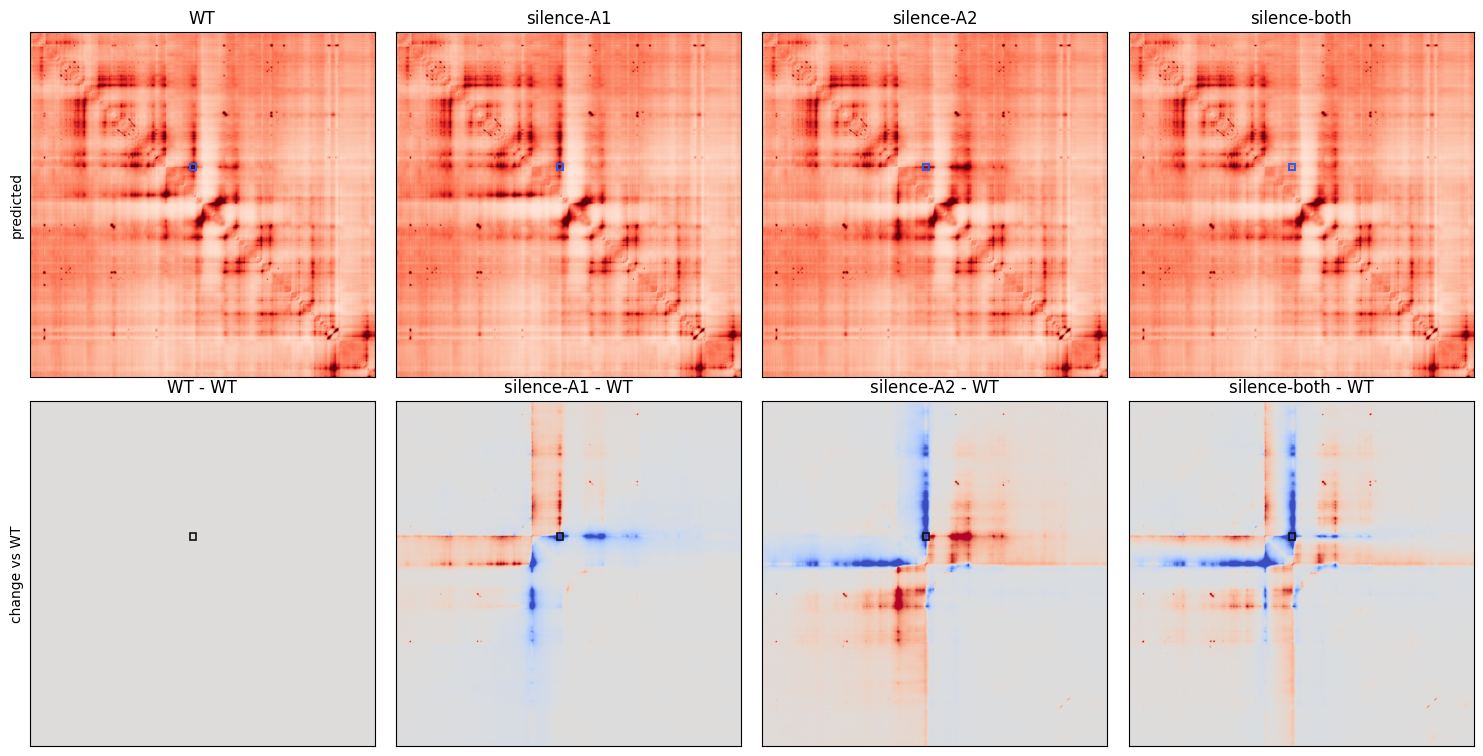

In [18]:
order = ['WT', 'silence-A1', 'silence-A2', 'silence-both']
vmax = np.nanpercentile(maps['WT'], 99.5)
dmax = np.nanpercentile(np.abs(maps['silence-both'] - maps['WT']), 99.5)
fig, ax = plt.subplots(2, 4, figsize=(15, 7.6))
for j, name in enumerate(order):
    ax[0, j].imshow(maps[name], cmap='Reds', vmin=0, vmax=vmax)
    ax[0, j].add_patch(Rectangle((A2_BIN-9, A1_BIN-9), 18, 18, fill=False, ec='#2563eb', lw=1.4))
    ax[0, j].set_title(name); ax[0, j].set_xticks([]); ax[0, j].set_yticks([])
    d = maps[name] - maps['WT']
    ax[1, j].imshow(d, cmap='coolwarm', vmin=-dmax, vmax=dmax)
    ax[1, j].add_patch(Rectangle((A2_BIN-9, A1_BIN-9), 18, 18, fill=False, ec='#111', lw=1.2))
    ax[1, j].set_title(f'{name} - WT'); ax[1, j].set_xticks([]); ax[1, j].set_yticks([])
ax[0,0].set_ylabel('predicted'); ax[1,0].set_ylabel('change vs WT')
plt.tight_layout(); plt.show()

In [19]:
# quantify: loop strength = mean of a small patch at the loop pixel, relative to WT
def loop_strength(m):
    return float(m[A1_BIN-3:A1_BIN+4, A2_BIN-3:A2_BIN+4].mean())
wt = loop_strength(maps['WT'])
print(f'{'condition':14s} {'loop strength':>14s} {'vs WT':>8s}')
for name in order:
    s = loop_strength(maps[name])
    print(f'{name:14s} {s:14.3f} {s/wt*100:7.0f}%')

condition       loop strength    vs WT
WT                      9.921     100%
silence-A1              3.693      37%
silence-A2              2.486      25%
silence-both            1.206      12%


## Takeaway
The model attributes the loop to **both** anchors: silencing either one weakens it, and silencing both collapses it — consistent with a CTCF/cohesin loop that needs both anchors. The whole screen is a single `predict_region` call; swap in coordinates, conditions, or another Manta head and repeat. See `docs/INFERENCE.md` for the conventions and the rest of the API.